In [611]:
import numpy
import matplotlib.pyplot as plt
import scipy
import pandas
import seaborn

print("All imports OK")
print(numpy.__file__)
print(plt.__file__)

All imports OK
/home/govind/gov_semproject/GridCellsTheta/GridCellsCond/.venv/lib/python3.13/site-packages/numpy/__init__.py
/home/govind/gov_semproject/GridCellsTheta/GridCellsCond/.venv/lib/python3.13/site-packages/matplotlib/pyplot.py


In [612]:
from neuron import h
h.load_file('stdrun.hoc')
import numpy as np
import matplotlib.pyplot as plt
import stellate
import interneuron_amb
import importlib
importlib.reload(stellate)
h.celsius = 37.0
h.steps_per_ms = 40
h.dt = 0.025
h.cvode_active(0)

0.0

In [613]:
stellate_0 = stellate.Stellate(0)
interneuron_0 = interneuron_amb.Interneuron(0)

In [614]:
stell_ic_0 = h.IClamp(stellate_0.soma(0.5))
stell_ic_0.dur = 1e9

sim_dur = 10000 #in ms
num_steps = int(sim_dur/h.dt)
time_arr = np.arange(0,sim_dur,h.dt)

stell_v = h.Vector().record(stellate_0.soma(0.5)._ref_v)
stellate_gh_vec = h.Vector().record(stellate_0.soma(0.5).stellate_mech._ref_gh)
stellate_gnap_vec = h.Vector().record(stellate_0.soma(0.5).stellate_mech._ref_gna)
nc_stell = h.NetCon(stellate_0.soma(0.5)._ref_v, None, sec=stellate_0.soma)
nc_stell.threshold = 0
spike_times_stell = h.Vector()
nc_stell.record(spike_times_stell)
time = h.Vector().record(h._ref_t)



In [615]:
syn_inh = h.ExpSyn(stellate_0.soma(0.5))
syn_inh.e = -80
syn_inh.tau = 5


n_points = len(time_arr)

stell_ic = h.IClamp(stellate_0.soma(0.5))
stell_ic.dur = 1e9
dc_val = 0
inhib_dc = np.full(n_points,dc_val,dtype=np.float64)
stell_dc_vec = h.Vector(inhib_dc)
stell_dc_vec.play(stell_ic._ref_amp,h.dt)

g_max = 0.004
g_min = 0.000

g_amp = 0.0001
theta_freq = 8.0

init_phase = 2*np.pi*(np.random.random())
theta_arr = g_amp*(np.sin((init_phase)+2*np.pi*theta_freq*time_arr/1000))


idx_1 = int(2000/h.dt)
idx_2 = int(4000/h.dt)
idx_3 = int(8000/h.dt)



tau_rise = 500.0
tau_fall = 1200.0

inhib_cond_arr = np.full(n_points, g_max,dtype=np.float64)
t_phase1 = time_arr[idx_1:idx_3] - time_arr[idx_1]
inhib_cond_arr[idx_1:idx_3] = ((g_max-g_min) * np.exp(-t_phase1 / tau_fall))+g_min
#inhib_cond_arr[idx_2:idx_3] = inhib_cond_arr[idx_2 - 1]
t_phase3 = time_arr[idx_3:] - time_arr[idx_3]
start_val = inhib_cond_arr[idx_3 - 1]
inhib_cond_arr[idx_3:] = start_val + (g_max - start_val) * (1 - np.exp(-t_phase3 / tau_rise))
noise = np.random.normal(loc=0, scale=1e-4, size=n_points)
inhib_cond_arr += noise
inhib_cond_arr += theta_arr

g_vec = h.Vector(inhib_cond_arr)
g_vec.play(syn_inh._ref_g, h.dt)
g_rec = h.Vector().record(syn_inh._ref_g)




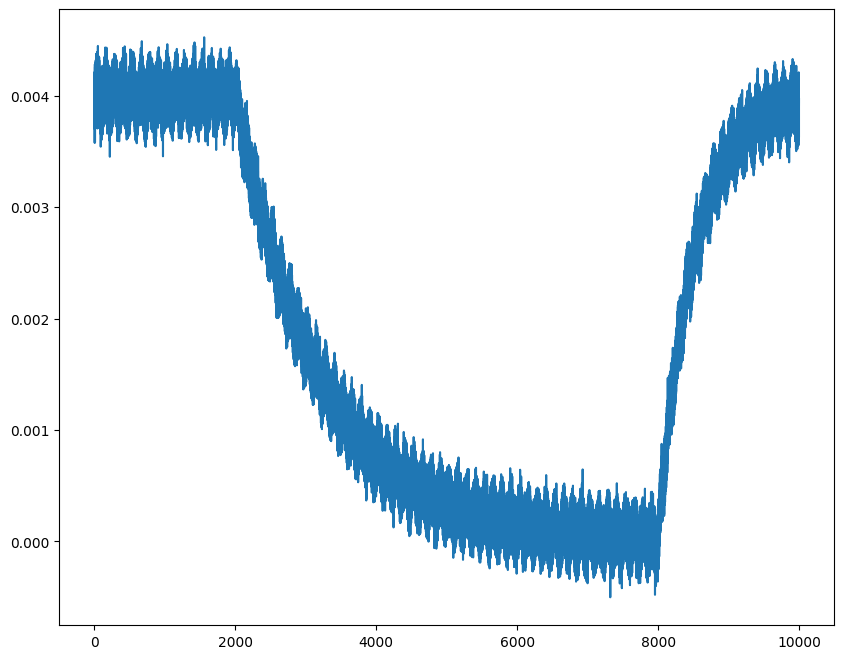

In [616]:
plt.figure(figsize=(10,8))
plt.plot(time_arr,inhib_cond_arr)

In [620]:
h.finitialize(-80)
h.frecord_init()
h.continuerun(sim_dur)

0.0

In [621]:
#phase extraction

spikes_arr = np.array(spike_times_stell.to_python())
phases = ((init_phase+((spikes_arr) * theta_freq * 2 * np.pi / 1000)) % (2 * np.pi))

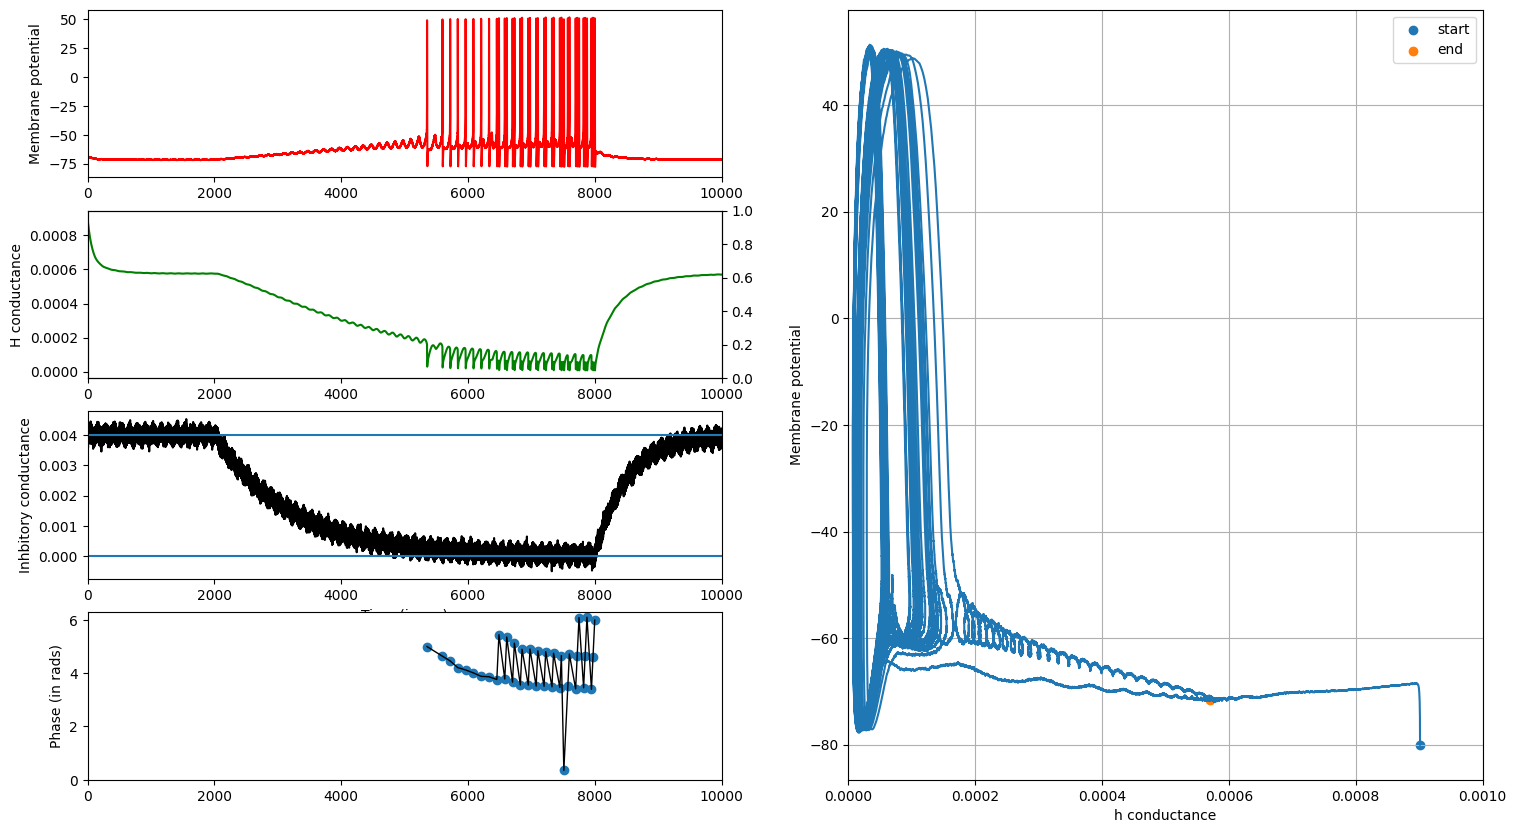

In [623]:
from matplotlib.gridspec import GridSpec

gh_cond = stellate_gh_vec.to_python()
gnap_cond = stellate_gnap_vec.to_python()
memb_pot = stell_v.to_python()
start_time = 0
end_time =  10000
start_idx = int(start_time/h.dt)
end_idx = int(end_time/h.dt)

fig = plt.figure(figsize=(18,10))

gs = GridSpec(4,2,width_ratios=[1,1])
ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[1,0])
ax1_1 = ax1.twinx()
ax2 = fig.add_subplot(gs[2,0])
ax3 = fig.add_subplot(gs[3,0])

ax_phase = fig.add_subplot(gs[:,1])


ax1.plot(time_arr[start_idx:end_idx],gh_cond[start_idx:end_idx],color='green')
ax2.set_xlabel("Time (in ms)")
ax2.set_ylabel("Inhbitory conductance")
ax1.set_ylabel("H conductance")
#ax1_1.plot(time_arr[start_idx:end_idx],gnap_cond[start_idx:end_idx],color='purple')
ax0.set_ylabel("Membrane potential")
ax0.plot(time_arr[start_idx:end_idx],memb_pot[start_idx:end_idx],color='red')
ax2.plot(time_arr[start_idx:end_idx],inhib_cond_arr[start_idx:end_idx],color='black')
ax2.axhline(y=g_max)
ax2.axhline(y=g_min)
ax3.plot(spikes_arr,phases,linewidth=1,color='black')
ax3.scatter(spikes_arr,phases)
ax3.set_ylabel("Phase (in rads)")
ax3.set_ylim(0,2*np.pi)
ax_phase.plot(gh_cond[start_idx:end_idx],memb_pot[start_idx:end_idx])
ax_phase.scatter(gh_cond[start_idx],memb_pot[start_idx],label='start')
ax_phase.scatter(gh_cond[end_idx],memb_pot[end_idx],label='end')
ax_phase.legend()
ax_phase.set_xlabel("h conductance")
ax_phase.set_ylabel("Membrane potential")
ax_phase.set_xlim(0,0.001)
ax0.set_xlim(start_time,end_time)
ax1.set_xlim(start_time,end_time)
ax2.set_xlim(start_time,end_time)
ax3.set_xlim(start_time,end_time)
#ax1.set_ylim(0,0.0007)
plt.grid(True)
plt.show()





In [517]:
print(phases)

[1.06785199 5.95617016 4.68319682 4.89305521 4.60277204 4.35144463
 4.30117915 4.26599331 4.23457738 4.31500216 4.29489596 4.29363933
 4.31248888 4.27855968 4.29363933 4.25594021 4.28358623 4.28986941
 4.33259507 4.29489596 4.30997561]
